In [1]:
import polars as pl
import datetime as dt
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from sklearn.metrics import mean_squared_log_error



# 🛒 Store Sales Time Series Forecasting: Exploratory Data Analysis (EDA)

Most of EDA is contained within streamlit dashboard

Command to run dashboard locally:

streamlit run app.py



## 📂 Project & Data Overview
The goal of this project is to forecast daily sales for thousands of product families sold at Favorita stores located in Ecuador. The dataset comprises 7 relational tables:

1. **`train.csv`**: The core historical time series (Daily total sales and number of items on promotion per store and product family).
2. **`test.csv`**: The 15-day future forecasting window we need to predict.
3. **`transactions.csv`**: Daily total transaction count (foot traffic) per store. *(Note: Blank for the test period).*
4. **`stores.csv`**: Metadata for the 54 stores (City, State, Type, and Cluster).
5. **`oil.csv`**: Daily price of crude oil (Ecuador's economy is highly dependent on oil).
6. **`holidays_events.csv`**: Metadata regarding national, regional, and local holidays, including bridge days and transferred holidays.
7. **`sample_submission.csv`**: The required formatting for Kaggle predictions.

---

## 📊 Key Insights & Findings

### 1. The Macro Picture: Sales Volume vs. Foot Traffic (Inflation Effect)
* **Revenue is growing, but foot traffic is shrinking:** Average total *sales* have steadily increased year-over-year from 2013 to 2017. However, the total number of *transactions* has actually slightly decreased over the same period. 
* **Insight:** This divergence strongly indicates that unit-price inflation—rather than organic customer growth—is driving the increased sales figures. 
* **The Promotion Shift:** Starting in 2015, promotions became significantly more frequent. Over time, the variance and frequency of promotions steadily increased, suggesting Corporacion Favorita fundamentally changed its marketing strategy to rely heavily on discounting to drive revenue. 

### 2. Temporal Patterns & Seasonality
* **Yearly Seasonality:** A "normal" year (using 2013 as a baseline) exhibits relatively steady sales throughout the year with a massive seasonal spike in late November and December (holiday shopping).
* **Weekly Seasonality:** Sales follow a right-skewed "U-shape" distribution throughout the week. Foot traffic and sales hit their lowest points mid-week (Wednesday/Thursday) and peak significantly on weekends (Saturday/Sunday).
* **Monthly Seasonality:** Sales peak at the very beginning of the month, remain relatively steady, and exhibit slight dips toward the end of the month.
* **Payday Effects:** Ecuador's public and private sectors generally pay employees on the 15th and the last day of the month. The data shows a slight, but measurable, bump in sales on and immediately following these paydays.
* **Autocorrelation (ACF/PACF):** Time series math confirms the visual EDA. There is significant autocorrelation at `lag = 1` (yesterday) and at multiples of 7 (`lags 7, 14, 21, 28...`), proving rigid weekly seasonality. There is also minor monthly seasonality evident in the lags. *ARIMA/Tree-based models will require robust lag engineering to capture this.*

### 3. The 2016 Earthquake Anomaly (Critical Data Event)
* On **April 16, 2016**, a massive magnitude 7.8 earthquake struck Manabí, Ecuador.
* **Data Impact:** This caused a massive, highly unusual spike in supermarket sales that lasted for roughly two months. This was driven by widespread stockpiling of essential goods (water, groceries) and nationwide donation efforts.
* **Modeling Implication:** This period must be treated carefully (e.g., via anomaly flagging) so machine learning models do not learn to expect this artificial spike every April.

### 4. External Factors: Oil & The Economy
Ecuador's macroeconomy is heavily tied to oil exports. The `oil.csv` data maps directly to the country's economic health:
* **2013:** Prices were stable, rising to a peak around October 2013 before normalizing.
* **2014:** Steady increases until July.
* **The Crash (Late 2014 - Early 2016):** Oil prices collapsed dramatically from September 2014 through January 2015. After a brief dead-cat bounce, they hit rock bottom in January 2016. 
* **Economic Ripple Effect:** This timeline perfectly aligns with the erratic behavior seen in the `train` dataset. The 2014 sales time series is highly jagged and volatile. By May 2015, the continuous upward trend in sales (despite flat transactions) likely reflects the severe inflation caused by the oil-induced economic crisis.

### 5. Promotional Impact
* **Coverage:** Promotions are a major driver of overall volume. Around 20% of all transactions involve a promotion, but roughly **65% of total sales volume** is attached to promoted items.
* **Correlation:** There is a moderate positive correlation (`0.428`) between sales and the number of items on promotion.
* **Variance:** While nominal variance is around 150, the variance of promotions as a percentage of overall sales is tightly clustered (`0.003`), showing predictable consumer reliance on deals.

### 6. Store Geography & Product Hierarchy
* **Store Dominance:** Stores designated as **Type A** vastly outperform Types B, C, D, and E in overall sales. 
* **Cluster Performance:** Store **Cluster 5** generates significantly more sales than any other cluster (likely representing mega-stores). Clusters 8, 11, 14, and 17 are also top performers.
* **The Capital Advantage:** Stores located in the capital city of **Quito** generate a staggering **52% of all national sales**.
* **Product Hierarchy:** The top-selling product families are, in order: 1. Groceries, 2. Beverages, 3. Produce.

### 7. The Complexity of Holidays
* Surprisingly, standard holidays have a smaller overall effect on sales than intuitively expected. 
* **The "Transfer" Nuance:** The impact depends heavily on the *type* of holiday (Additional, Transfer, Bridge, Event, Work Day). Due to Ecuador's labor laws, holidays falling on mid-week days are often "Transferred" to Mondays or Fridays.
* Furthermore, to make up for "Bridge" days (long weekends), the government often mandates subsequent Saturdays as official "Work Days," which completely inverted the normal weekend sales spikes on those specific dates.
* **Location Scope:** A holiday only impacts sales if the scope (Local, Regional, National) matches the Store's exact City or State.




In [2]:
# 1. Load Raw Data
train_raw = pd.read_csv('store-sales-time-series-forecasting/train.csv')
test_raw = pd.read_csv('store-sales-time-series-forecasting/test.csv') # The Kaggle submission set

oil_raw = pd.read_csv('store-sales-time-series-forecasting/oil.csv')
stores_raw = pd.read_csv('store-sales-time-series-forecasting/stores.csv')
holidays_raw = pd.read_csv('store-sales-time-series-forecasting/holidays_events.csv')


In [3]:
# analysis of holidays

unique_holiday_type = holidays_raw['type'].unique()
print("Unique Holiday Types")
print(unique_holiday_type)

unique_holiday_locale = holidays_raw['locale'].unique()
print("Unique Holiday locale")
print(unique_holiday_locale)


Unique Holiday Types
['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']
Unique Holiday locale
['Local' 'Regional' 'National']


In [4]:
# analysis of holidays

# find unique holiday location names, where holiday locale is 'Local'
local_holiday_locations = set(holidays_raw[holidays_raw['locale'] == 'Local']['locale_name'].unique())
print("Unique Local Holiday Locations")
print(local_holiday_locations)

regional_holiday_locations = set(holidays_raw[holidays_raw['locale'] == 'Regional']['locale_name'].unique())
print("Unique Regional Holiday Locations")
print(regional_holiday_locations)

Unique Local Holiday Locations
{'Ambato', 'Salinas', 'Guayaquil', 'Cayambe', 'Latacunga', 'Esmeraldas', 'Quito', 'Loja', 'Santo Domingo', 'Manta', 'Quevedo', 'Riobamba', 'El Carmen', 'Ibarra', 'Machala', 'Cuenca', 'Guaranda', 'Puyo', 'Libertad'}
Unique Regional Holiday Locations
{'Santa Elena', 'Santo Domingo de los Tsachilas', 'Imbabura', 'Cotopaxi'}


In [5]:
# unique store cities
unique_store_cities = set(stores_raw['city'].unique())
print("Unique Store Cities")
print(unique_store_cities)

# unique store states
unique_store_states = set(stores_raw['state'].unique())
print("Unique Store States")
print(unique_store_states)

Unique Store Cities
{'Ambato', 'Guayaquil', 'Salinas', 'Cayambe', 'Latacunga', 'Esmeraldas', 'Quito', 'Loja', 'Santo Domingo', 'Manta', 'Daule', 'Quevedo', 'Riobamba', 'El Carmen', 'Ibarra', 'Machala', 'Guaranda', 'Cuenca', 'Babahoyo', 'Puyo', 'Playas', 'Libertad'}
Unique Store States
{'Los Rios', 'Esmeraldas', 'Pastaza', 'Santa Elena', 'Santo Domingo de los Tsachilas', 'Loja', 'Azuay', 'Manabi', 'Pichincha', 'El Oro', 'Tungurahua', 'Chimborazo', 'Bolivar', 'Guayas', 'Imbabura', 'Cotopaxi'}


In [6]:
# find unique store cities that aren't in the unique holiday cities
# find difference between these two sets of unique locations
unique_store_cities_not_in_holiday = unique_store_cities.difference(local_holiday_locations)
print("Unique Store Cities that aren't in Local Holiday Locations")
print(unique_store_cities_not_in_holiday)

unique_holiday_cities_not_in_store_cities = local_holiday_locations.difference(unique_store_cities)
print("Unique Holiday Cities that aren't in Store Cities")
print(unique_holiday_cities_not_in_store_cities)

Unique Store Cities that aren't in Local Holiday Locations
{'Daule', 'Babahoyo', 'Playas'}
Unique Holiday Cities that aren't in Store Cities
set()


In [7]:
# find unique store regions that aren't in the unique holiday regions
# find difference between these two sets of unique locations
unique_store_regions_not_in_holiday = unique_store_states.difference(regional_holiday_locations)
print("Unique Store Regions that aren't in Regional Holiday Locations")
print(unique_store_regions_not_in_holiday)

unique_holiday_regions_not_in_store_regions = regional_holiday_locations.difference(unique_store_states)
print("Unique Holiday Regions that aren't in Store Regions")
print(unique_holiday_regions_not_in_store_regions)

Unique Store Regions that aren't in Regional Holiday Locations
{'Los Rios', 'Esmeraldas', 'Pastaza', 'Loja', 'Azuay', 'Manabi', 'Pichincha', 'El Oro', 'Tungurahua', 'Chimborazo', 'Bolivar', 'Guayas'}
Unique Holiday Regions that aren't in Store Regions
set()


From above, we see there are no Holiday regions/cities that aren't in store regions/cities - so we can create a link between holidays and stores very easily in our pre-processing pipeline.

In [8]:
# create custom preprocessor as standard scikit-learn pipelines don't natively handle relational
# database operations like pd.merge() or temporal operations like reindexing calendars.


class StoreSalesPreprocessor(BaseEstimator, TransformerMixin):
    """
    Custom Scikit-Learn Transformer for the Kaggle Store Sales Competition.
    Handles dates, oil interpolation, and relational table merges.
    """
    def __init__(self, oil_df, stores_df, holidays_df=None, lag_features=None, lag_values=None):
        # Pass the auxiliary dataframes when initializing the pipeline
        self.oil_df = oil_df.copy()
        self.stores_df = stores_df.copy()
        self.holidays_df = holidays_df.copy() if holidays_df is not None else None
        # lag_features: list of strings, e.g., ['onpromotion', 'transactions']
        # lag_values: dict of lists, e.g., {'onpromotion': [16, 21, 28], 'transactions': [16, 17]}
        self.lag_features = lag_features if lag_features is not None else []
        self.lag_values = lag_values if lag_values is not None else {}
        
    def fit(self, X, y=None):
        """
        The fit method learns parameters from the training data.
        We process the auxiliary tables here so it only happens once.
        """
        print("Fitting pipeline: Processing auxiliary tables...")
        
        self.processed_oil_ = self._process_oil(self.oil_df)
        self.processed_stores_ = self._process_stores(self.stores_df)

        self.processed_holidays_ = self._process_holidays(self.holidays_df)
        
        return self

    def transform(self, X):
        """
        The transform method applies the merges to the Train or Test data.
        """
        print(f"Transforming data ({len(X)} rows)...")
        X_out = X.copy()

        # Save the exact original index and row order
        original_index = X_out.index
        X_out['__original_index'] = original_index
        
        X_out['date'] = pd.to_datetime(X_out['date'])
        
        X_out = pd.merge(X_out, self.processed_oil_, on='date', how='left')
        
        X_out = pd.merge(X_out, self.processed_stores_, on='store_nbr', how='left')
        
        X_out = pd.merge(X_out, self.processed_holidays_, on='date', how='left')
        # Initialize the column to 0
        X_out['does_holiday_affect_store'] = 0
        X_out['is_makeup_work_day'] = 0
        
        # Geographic matching masks
        is_national = X_out['holiday_location'] == 'National'
        is_regional = (X_out['holiday_location'] == 'Regional') & (X_out['store_state'] == X_out['holiday_location_name'])
        is_local = (X_out['holiday_location'] == 'Local') & (X_out['store_city'] == X_out['holiday_location_name'])
        
        # Transferred holidays are celebrated on a different day, so they don't count TODAY
        # (Be careful with NaNs from days that have no holidays at all)
        affected_by_geo = is_national | is_regional | is_local
        
        # Is it truly a day off? (Not a makeup work day, and not transferred away)
        is_day_off = (X_out['holiday_type'] != 'Work Day') & (X_out['holiday_transferred'] == False)
        
        # Is it a makeup work day?
        is_work_day = X_out['holiday_type'] == 'Work Day'
        
        # Apply the masks
        X_out.loc[affected_by_geo & is_day_off, 'does_holiday_affect_store'] = 1
        X_out.loc[affected_by_geo & is_work_day, 'is_makeup_work_day'] = 1

        # Because some dates have multiple holidays, pd.merge creates duplicates.
        # This guarantees we return the EXACT same number of rows we started with.
        X_out = X_out.sort_values(by=['does_holiday_affect_store', 'is_makeup_work_day'], ascending=[False, False])
        X_out = X_out.drop_duplicates(subset=['__original_index'], keep='first')

        # Restore the exact original row order and original index
        X_out = X_out.set_index('__original_index').loc[original_index]
        X_out.index.name = None # clean up the index name

        # Extract base calendar features (always good to have in the pipeline)
        X_out['day_of_week'] = X_out['date'].dt.dayofweek
        X_out['month'] = X_out['date'].dt.month
        X_out['year'] = X_out['date'].dt.year
        X_out['is_weekend'] = X_out['day_of_week'].isin([5, 6]).astype(int)

        # (Earthquake & Paydays)
        # Paydays: 15th of the month and last day of the month
        X_out['is_payday'] = ((X_out['date'].dt.day == 15) | (X_out['date'].dt.is_month_end)).astype(int)
        
        # Earthquake Anomaly (April 16, 2016 to approx mid-June 2016)
        X_out['is_earthquake_impact'] = ((X_out['date'] >= '2016-04-16') & (X_out['date'] <= '2016-06-16')).astype(int)
        
        # 7. Lag Generation (t-16 to t-21 to capture the rigid weekly seasonality safely)
        if self.lag_features and self.lag_values:
            X_out = self._generate_lags(X_out)
            X_out = X_out.fillna(0) 
            
        return X_out
    
    def _generate_lags(self, df):
        """Generates specific lags per feature based on dictionary mapping."""
        df = df.sort_values(['store_nbr', 'family', 'date'])
        
        for feature in self.lag_features:
            # Check if the feature exists in the df AND if it has designated lag values in the dict
            if feature in df.columns and feature in self.lag_values:
                
                # Extract the specific array of lags for this particular feature
                specific_lags = self.lag_values[feature]
                
                for lag in specific_lags:
                    new_col_name = f'{feature}_lag_{lag}'
                    df[new_col_name] = df.groupby(['store_nbr', 'family'])[feature].shift(lag)
                    
        return df

    def _process_oil(self, oil):
        """Helper method to encapsulate the oil interpolation logic"""
        oil['date'] = pd.to_datetime(oil['date'])
        
        # Create continuous calendar bounds based on the oil dataset
        calendar = pd.date_range(start=oil['date'].min(), end=oil['date'].max())
        
        # Reindex and Interpolate
        oil_continuous = oil.set_index('date').reindex(calendar).rename_axis('date').reset_index()
        
        # forward fill, then backward fill for the very first missing day (Jan 1, 2013)
        oil_continuous['dcoilwtico'] = oil_continuous['dcoilwtico'].ffill().bfill()
        
        # Rename column for clarity
        oil_continuous = oil_continuous.rename(columns={'dcoilwtico': 'oil_price'})
        # Create a rolling oil average (helps smooth the volatile 2014-2016 crash)
        oil_continuous['oil_price_7d_avg'] = oil_continuous['oil_price'].rolling(7, min_periods=1).mean()
        
        return oil_continuous
    
    def _process_holidays(self, holidays):
        holidays['date'] = pd.to_datetime(holidays['date'])
        holidays = holidays.rename(columns={
            'locale': 'holiday_location', 
            'locale_name': 'holiday_location_name', 
            'type': 'holiday_type', 
            'description': 'holiday_description',  
            'transferred': 'holiday_transferred'
        })
        return holidays
    
    def _process_stores(self, stores):
        """Helper method to transform stores so it can be incorporated with other tables"""

        stores = stores.rename(columns={'city': 'store_city', 'state': 'store_state', 'type': 'store_type', 'cluster': 'store_cluster'})

        return stores



### Classical Timeseries Models
1. **Models** Slowly build up - start with ARMA, SARIMA, then SARIMAX
2. **SARIMAX** Create robust lag variables/differencing (`t-7`,`t-16` to `t-30`) to make timeseries weakly stationary (dickey fuller test)- also can't use transactions dataset in X - how to potentially impute?
3. **Prophet:** No need for differencing - also can include holidays.
4. **ARCH and GARCH:** as covariance will definitely not be very stationary.
5. **Training:** Use last 15 days as validation set - use Information Criteria to avoid overfitting
6. **Cross Correlation:** Check for cross correlation between external factors, and prewhiten where necessary
7. **Extra models:** Spectral Analysis, Vector Autoregressive Models, Might be a nice extra addition
8. **ML Models:**
9. **Quant additions to ML models:**

## Sarimax

Here we create a wrapper class for the SARIMAX model. Important parameters in the SARIMAX model are

- endog: observed time-series process (ie 'sales') (1 x N)
- exog: exogeneous regressors (k x N, where we have k exogeneous variables)
- order: (p,d,q) order of model
- seasonal_order: (P,D,Q,s), here we set s=7 due to weekly seasonality

In [9]:
class SARIMAXWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7), exog_cols=None):
        self.order = order
        self.seasonal_order = seasonal_order
        self.exog_cols = exog_cols # e.g., ['onpromotion', 'is_payday', 'is_earthquake_impact', 'oil_price']
        self.model_ = None
        
    def fit(self, X, y):
        # STRIP PANDAS INDICES COMPLETELY BY CONVERTING TO NUMPY ARRAYS
        endog_array = np.asarray(y, dtype=float)
        exog_array = np.asarray(X[self.exog_cols], dtype=float) if self.exog_cols else None
        
        # Fit SARIMAX
        self.model_ = sm.tsa.statespace.SARIMAX(
            endog=endog_array,
            exog=exog_array,
            order=self.order,
            seasonal_order=self.seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        return self
        
    def predict(self, X):
        # Convert test exogenous data to numpy arrays as well
        exog = np.array(X[self.exog_cols].astype(float) if self.exog_cols else None)
        
        # Predict the exact number of steps in the test set (e.g., 15 days)
        steps = len(X)
        forecast = self.model_.forecast(steps=steps, exog=exog)
        return forecast if isinstance(forecast, np.ndarray) else forecast.values


Below we create a function which builds pipeline with SARIMAX model and outputs RMSLE values and does a p-test checking for stationarity, given parameters of:

- store_list - list of all stores to model
- family_list - list of all product families to model
- exog_cols - exogenenous variables to include in SARIMAX
- lag_features - list of all features to lag
- lag_values - dictionary of lag_values for each lag_feature in lag_features

In [10]:
import itertools
from statsmodels.tsa.stattools import adfuller

def train_multiple_series_sarimax(train_raw, oil_raw, stores_raw, holidays_raw, 
                          store_list, family_list, exog_cols, 
                          lag_features, lag_values, limit=None):
    """
    Instantiates the pipeline dynamically, checks lag configurations, 
    tests for stationarity, and fits SARIMAX.
    """
    
    # ---------------------------------------------------------
    # 1. VALIDATION TEST: Ensure exogenous lags are actually used
    # ---------------------------------------------------------
    expected_exog_lags = []
    for feature in lag_features:
        if feature != 'sales' and feature in lag_values: # Exclude target from exog test
            for lag in lag_values[feature]:
                expected_exog_lags.append(f'{feature}_lag_{lag}')
                
    missing_cols = [col for col in expected_exog_lags if col not in exog_cols]
    if missing_cols:
        raise ValueError(
            f"Validation Failed! The preprocessor is generating lags that are missing from exog_cols.\n"
            f"Please add these to exog_cols: {missing_cols}"
        )
    print("Validation Passed: All generated exogenous lags are present in exog_cols.\n")
    # ---------------------------------------------------------
    
    results = []
    combinations = list(itertools.product(store_list, family_list))
    if limit:
        combinations = combinations[:limit]
        
    for store_nbr, family in combinations:
        print(f"--- Processing Store: {store_nbr} | Family: {family} ---")

    
        
        # Subset Data
        df_sub = train_raw[(train_raw['store_nbr'] == store_nbr) & (train_raw['family'] == family)].copy()
        df_sub['date'] = pd.to_datetime(df_sub['date'])
        
        if len(df_sub) < 100:
            print("Not enough data. Skipping.")
            continue

        # Check if the data is completely flat (e.g., 0 sales every day)
        if df_sub['sales'].nunique() <= 1:
            # print(f"  -> Series is constant (0 variance). Skipping ADF test.")
            p_val = 0.0
            is_stationary = True
            d_order = 0
        else:
            try:
                adf_result = adfuller(df_sub['sales'].dropna())
                p_val = adf_result[1]
                is_stationary = p_val <= 0.05
                d_order = 0 if is_stationary else 1
                print(f"ADF p-value: {p_val:.4f} -> {'Stationary (d=0)' if is_stationary else 'NON-Stationary (d=1)'}")

            except Exception as e:
                # If ADF fails for any other weird mathematical reason, safely default to d=1
                # print(f"  -> ADF test failed, assuming non-stationary. Error: {e}")
                p_val = 1.0 
                is_stationary = False
                d_order = 1
        # ---------------------------------------------------------
        # 2. INSTANTIATE PREPROCESSOR INSIDE THE LOOP
        # ---------------------------------------------------------
        preprocessor_inst = StoreSalesPreprocessor(
            oil_df=oil_raw, 
            stores_df=stores_raw, 
            holidays_df=holidays_raw, 
            lag_features=lag_features, 
            lag_values=lag_values
        )
        
        pipeline = Pipeline([
            ('preprocessor', preprocessor_inst),
            ('sarimax', SARIMAXWrapper(
                order=(1, d_order, 1), 
                seasonal_order=(1, 0, 1, 7), 
                exog_cols=exog_cols
            ))
        ])
        
        # Train/Val Split
        val_cutoff = df_sub['date'].max() - pd.Timedelta(days=15)
        X_train = df_sub[df_sub['date'] <= val_cutoff]
        y_train = X_train['sales']
        X_val = df_sub[df_sub['date'] > val_cutoff]
        y_val = X_val['sales']
        
        # Fit and Evaluate
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)
        
        rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))
        print(f"RMSLE: {rmsle:.4f}\n")
        
        results.append({
            'store_nbr': store_nbr,
            'family': family,
            'is_stationary': is_stationary,
            'rmsle': rmsle,
            'pipeline_model': pipeline 
        })
        
    return results


In [11]:
# Define our settings
# here we look at lags for onpromotion - due to hoarding consumer patterns with promotions
lag_feats = ['onpromotion']
lag_vals = {
    'onpromotion': [16, 21, 28]
}

# Explicitly list all exogenous columns we intend to feed into SARIMA
exogenous_features = [
    'is_payday', 
    'is_earthquake_impact',
    'does_holiday_affect_store',
    'onpromotion_lag_16',
    'onpromotion_lag_21',
    'onpromotion_lag_28'
]

# Run the function
run_results = train_multiple_series_sarimax(
    train_raw=train_raw, 
    oil_raw=oil_raw, 
    stores_raw=stores_raw, 
    holidays_raw=holidays_raw, 
    store_list=[1, 2], 
    family_list=['GROCERY I', 'BEVERAGES'], 
    exog_cols=exogenous_features, 
    lag_features=lag_feats, 
    lag_values=lag_vals, 
    limit=2
)

Validation Passed: All generated exogenous lags are present in exog_cols.

--- Processing Store: 1 | Family: GROCERY I ---
ADF p-value: 0.0008 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...


/Users/K1429214/Documents/Learning/predicting_sales/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Transforming data (15 rows)...
RMSLE: 0.3022

--- Processing Store: 1 | Family: BEVERAGES ---
ADF p-value: 0.0255 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
RMSLE: 0.3125



/Users/K1429214/Documents/Learning/predicting_sales/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


There are a lot of hyperparameters in the above function - if we were to perform some hyperparameter optimization for each individual timeseries we would do something like below. However, doing this sort of hyperparameter optimization for all timeseries would be very computationally expensive, and is out of the scope of this exploration. However, I've included the code just as a skeleton for how you would go about this - I've used the hyperopt library.

In [12]:
import sys
import types
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

# 1. Ignore all standard Python warnings (FutureWarnings, UserWarnings, Pandas SettingWithCopy, etc.)
warnings.filterwarnings("ignore")

# 2. Specifically mute statsmodels' mathematical complaints during Hyperopt's random searching
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', ValueWarning)
warnings.simplefilter('ignore', category=UserWarning)
# Create a dummy package in memory
sys.modules['pkg_resources'] = types.ModuleType('pkg_resources')

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import numpy as np
from sklearn.metrics import mean_squared_log_error
from sklearn.pipeline import Pipeline
import pandas as pd

# 1. Define the Global Search Space
space = {
    'p': hp.choice('p', [0, 1, 2]),
    'd': hp.choice('d', [0, 1]), # Note: You can also fix 'd' based on the Dickey-Fuller test
    'q': hp.choice('q', [0, 1, 2]),
    'P': hp.choice('P', [0, 1]),
    'D': hp.choice('D', [0, 1]),
    'Q': hp.choice('Q', [0, 1]),
    
    # We define the arrays of lags we want to test
    'lag_combinations': hp.choice('lag_combinations', [
        [16, 21, 28], 
        [16, 17, 18],
        [16, 17, 18, 21, 28] 
    ])
}

# 2. Define the Objective Function
def objective(params, train_raw, oil_raw, stores_raw, holidays_raw, store_nbr, family):
    # Subset Data
    df_sub = train_raw[(train_raw['store_nbr'] == store_nbr) & (train_raw['family'] == family)].copy()
    df_sub['date'] = pd.to_datetime(df_sub['date'])
    
    # Train/Val Split (Direct forecasting to avoid target leakage)
    val_cutoff = df_sub['date'].max() - pd.Timedelta(days=15)
    X_train = df_sub[df_sub['date'] <= val_cutoff]
    y_train = X_train['sales']
    X_val = df_sub[df_sub['date'] > val_cutoff]
    y_val = X_val['sales']
    
    # ---------------------------------------------------------
    # DYNAMIC PARAMETER CONSTRUCTION FOR THIS TRIAL
    # ---------------------------------------------------------
    chosen_lags = params['lag_combinations']
    
    # Create the dictionary format required by our new Preprocessor
    lag_feats = ['onpromotion']
    lag_vals_dict = {
        'onpromotion': chosen_lags
    }
    
    # Dynamically build the exact exog_cols list for SARIMAX
    base_exog = ['is_payday', 'is_earthquake_impact', 'does_holiday_affect_store']
    dynamic_exog = [f'onpromotion_lag_{l}' for l in chosen_lags]
    exog_cols = base_exog + dynamic_exog
    
    # Instantiate Preprocessor
    preprocessor_inst = StoreSalesPreprocessor(
        oil_df=oil_raw, 
        stores_df=stores_raw, 
        holidays_df=holidays_raw, 
        lag_features=lag_feats, 
        lag_values=lag_vals_dict
    )
    
    # Instantiate Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor_inst),
        ('sarimax', SARIMAXWrapper(
            order=(params['p'], params['d'], params['q']),
            seasonal_order=(params['P'], params['D'], params['Q'], 7), 
            exog_cols=exog_cols
        ))
    ])
    
    try:
        # Fit & Predict
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        
        # Clip negative predictions to 0
        y_pred = np.clip(y_pred, 0, None)
        
        # Calculate Loss
        rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))
        
        # Return loss for hyperopt to minimize
        return {'loss': rmsle, 'status': STATUS_OK}
    
    except Exception as e:
        # SARIMAX occasionally crashes on certain combinations (e.g., non-invertible roots).
        # We catch the exception and return a massive loss so Hyperopt learns to avoid this parameter area.
        return {'loss': 9999, 'status': STATUS_OK}

# 3. Main execution function
def run_hyperopt(train_raw, oil_raw, stores_raw, holidays_raw, store_nbr=1, family='GROCERY I', max_evals=20):
    print(f"Starting Hyperparameter Optimization for Store: {store_nbr} | Family: {family}")
    
    trials = Trials()
    
    best = fmin(
        fn=lambda params: objective(
            params, train_raw, oil_raw, stores_raw, holidays_raw, store_nbr, family
        ),
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals, 
        trials=trials
    )
    
    print("\n Best Parameters found by Hyperopt:")
    print(best)
    
    return best, trials




In [13]:
best_params, trial_history = run_hyperopt(
    train_raw=train_raw, 
    oil_raw=oil_raw, 
    stores_raw=stores_raw, 
    holidays_raw=holidays_raw, 
    store_nbr=1, 
    family='GROCERY I', 
    max_evals=15
)

Starting Hyperparameter Optimization for Store: 1 | Family: GROCERY I
Fitting pipeline: Processing auxiliary tables...      
Transforming data (1669 rows)...                      
Transforming data (15 rows)...                        
Fitting pipeline: Processing auxiliary tables...                                 
Transforming data (1669 rows)...                                                 
Transforming data (15 rows)...                                                   
Fitting pipeline: Processing auxiliary tables...                                 
Transforming data (1669 rows)...                                                
Transforming data (15 rows)...                                                  
Fitting pipeline: Processing auxiliary tables...                                 
Transforming data (1669 rows)...                                                 
Transforming data (15 rows)...                                                   
Fitting pipeline: Processing 

#### Analysis of SARIMAX model results

### Prophet (by Meta)

Prophet frames timeseries forecasting as a curve-fitting problem rather than an autoregressive one. We therefore drop the ADF tests and don't require any differencing.

However, Prophet has its own specific features we must utilize:

- Built-in Seasonality: It handles weekly and yearly seasonality natively.
- Built-in Holidays: It has a native add_country_holidays method, but we will also pass our custom does_holiday_affect_store feature to it, because Prophet's built-in holiday list doesn't know about local/regional specificities or makeup work days!
- Data Format: It strictly expects a dataframe with ds (datestamp) and y (target). We handle this cleanly inside the Scikit-Learn wrapper.


In [14]:
from prophet import Prophet
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np
import logging

# Suppress Prophet's extremely noisy logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").disabled = True

class ProphetWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, regressors=None, country_holidays='EC'):
        self.regressors = regressors if regressors is not None else []
        self.country_holidays = country_holidays
        self.model_ = None
        
    def fit(self, X, y):
        # Prophet strictly requires columns 'ds' and 'y'
        df = pd.DataFrame()
        df['ds'] = pd.to_datetime(X['date'].values)
        df['y'] = np.asarray(y, dtype=float)
        
        # Add exogenous regressors
        for reg in self.regressors:
            df[reg] = np.asarray(X[reg], dtype=float)
            
        self.model_ = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False # No intraday data
        )
        
        # 1. Native Prophet Feature: Country Holidays
        if self.country_holidays:
            self.model_.add_country_holidays(country_name=self.country_holidays)
            
        # 2. Add our custom features (Earthquake, Paydays, Lags, Local Holidays)
        for reg in self.regressors:
            self.model_.add_regressor(reg)
            
        self.model_.fit(df)
        return self
        
    def predict(self, X):
        df = pd.DataFrame()
        df['ds'] = pd.to_datetime(X['date'].values)
        
        for reg in self.regressors:
            df[reg] = np.asarray(X[reg], dtype=float)
            
        forecast = self.model_.predict(df)
        
        # Prophet returns a dataframe. We only want the predicted values ('yhat')
        return forecast['yhat'].values


In [15]:
import itertools
from sklearn.metrics import mean_squared_log_error
from sklearn.pipeline import Pipeline
import pandas as pd

def train_multiple_series_prophet(train_raw, oil_raw, stores_raw, holidays_raw, 
                                  store_list, family_list, exog_cols, 
                                  lag_features, lag_values, limit=None):
    """
    Instantiates pipelines natively utilizing Facebook Prophet's specific properties.
    """
    
    # ---------------------------------------------------------
    # VALIDATION TEST
    # ---------------------------------------------------------
    expected_exog_lags = []
    for feature in lag_features:
        if feature != 'sales' and feature in lag_values:
            for lag in lag_values[feature]:
                expected_exog_lags.append(f'{feature}_lag_{lag}')
                
    missing_cols = [col for col in expected_exog_lags if col not in exog_cols]
    if missing_cols:
        raise ValueError(
            f"Validation Failed! Preprocessor is generating lags missing from exog_cols.\n"
            f"Please add these: {missing_cols}"
        )
    print("Validation Passed: All generated exogenous lags are present in exog_cols.\n")
    
    results = []
    combinations = list(itertools.product(store_list, family_list))
    if limit:
        combinations = combinations[:limit]
        
    for store_nbr, family in combinations:
        print(f"--- Processing Store: {store_nbr} | Family: {family} ---")
        
        # 1. Subset Data
        df_sub = train_raw[(train_raw['store_nbr'] == store_nbr) & (train_raw['family'] == family)].copy()
        df_sub['date'] = pd.to_datetime(df_sub['date'])
        
        if len(df_sub) < 100:
            print("Not enough data. Skipping.")
            continue

        # 2. Instantiate Preprocessor dynamically
        preprocessor_inst = StoreSalesPreprocessor(
            oil_df=oil_raw, 
            stores_df=stores_raw, 
            holidays_df=holidays_raw, 
            lag_features=lag_features, 
            lag_values=lag_values
        )
        
        # 3. Instantiate Prophet Pipeline
        pipeline = Pipeline([
            ('preprocessor', preprocessor_inst),
            ('prophet', ProphetWrapper(
                regressors=exog_cols,
                country_holidays='EC' # Tell Prophet it's Ecuador!
            ))
        ])
        
        # 4. Train/Val Split (15 Days)
        val_cutoff = df_sub['date'].max() - pd.Timedelta(days=15)
        X_train = df_sub[df_sub['date'] <= val_cutoff]
        y_train = X_train['sales']
        X_val = df_sub[df_sub['date'] > val_cutoff]
        y_val = X_val['sales']
        
        # 5. Fit & Predict
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        
        # Handle Negative Predictions
        y_pred = np.clip(y_pred, 0, None)
        
        rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))
        print(f"Prophet RMSLE: {rmsle:.4f}\n")
        
        results.append({
            'store_nbr': store_nbr,
            'family': family,
            'rmsle': rmsle,
            'pipeline_model': pipeline 
        })
        
    return results


In [16]:
# Settings
lag_feats = ['onpromotion']
lag_vals = {
    'onpromotion': [16, 21, 28]
}

exogenous_features = [
    'is_payday', 
    'is_earthquake_impact',
    'does_holiday_affect_store', # We pass this so Prophet knows LOCAL holidays
    'onpromotion_lag_16',
    'onpromotion_lag_21',
    'onpromotion_lag_28'
]

# Run Prophet
prophet_results = train_multiple_series_prophet(
    train_raw=train_raw, 
    oil_raw=oil_raw, 
    stores_raw=stores_raw, 
    holidays_raw=holidays_raw, 
    store_list=[1, 2], 
    family_list=['GROCERY I'], 
    exog_cols=exogenous_features, 
    lag_features=lag_feats, 
    lag_values=lag_vals, 
    limit=2
)


Validation Passed: All generated exogenous lags are present in exog_cols.

--- Processing Store: 1 | Family: GROCERY I ---
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Prophet RMSLE: 0.2706

--- Processing Store: 2 | Family: GROCERY I ---
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Prophet RMSLE: 0.2444



#### Analysis of Prophet model results

### ARX-GARCH

In classical time series (like SARIMA or Prophet), there is a massive underlying assumption called Homoskedasticity: the assumption that the "noise" or "error" in the data has a constant variance over time. We've seen in our EDA that our timeseries data is not Homoskedastic (Oil crash, earthquake, and other volatility clusters).

Here we propose an ARX (Autoregrssive model with exogeneous variable) model to predict actual sales, combined with a Variance equation (GARCH) to model the changing volatility of the ARX model's errors.

By solving them simultaneously, the ARX mean predictions become much more accurate during volatile periods because the model isn't "confused" by the changing variance—it expects it.

Below, we create the ARX-GARCH Wrapper.







In [17]:
from arch import arch_model
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np
import warnings

class GARCHWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, mean_lags=1, vol_p=1, vol_q=1, exog_cols=None):
        self.mean_lags = mean_lags
        self.vol_p = vol_p
        self.vol_q = vol_q
        self.exog_cols = exog_cols if exog_cols is not None else []
        self.model_res_ = None
        
    def fit(self, X, y):
        # endog MUST be a numpy array to avoid Pandas index alignment issues
        endog = np.asarray(y, dtype=float)
        
        # exog is passed as a Pandas DataFrame so `arch` learns the column names!
        exog_df = X[self.exog_cols].astype(float) if self.exog_cols else None
        
        model = arch_model(
            y=endog, 
            x=exog_df, 
            mean='ARX', 
            lags=self.mean_lags, 
            vol='Garch', 
            p=self.vol_p, 
            q=self.vol_q,
            dist='Normal',
            rescale=False # Prevents scaling warnings for large sales numbers
        )
        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            self.model_res_ = model.fit(disp='off')
            
        return self
        
    def predict(self, X):
        steps = len(X)
        
        # FIX: The `arch` library requires future exogenous variables to be formatted
        # as a dictionary: {'col_name': 1D_array_of_values}
        if self.exog_cols:
            exog_dict = {col: X[col].values for col in self.exog_cols}
        else:
            exog_dict = None
            
        # The forecasts object originates from the last day in the training set
        forecasts = self.model_res_.forecast(horizon=steps, x=exog_dict)
        
        # Extract the point predictions for the mean (the actual sales)
        point_predictions = forecasts.mean.iloc[-1].values
        
        return point_predictions


In [18]:
import itertools
from sklearn.metrics import mean_squared_log_error
from sklearn.pipeline import Pipeline

def train_multiple_series_garch(train_raw, oil_raw, stores_raw, holidays_raw, 
                                store_list, family_list, exog_cols, 
                                lag_features, lag_values, limit=None):
    """
    Fits a joint ARX-GARCH model to handle periods of extreme variance 
    (like the 2016 Earthquake and 2015 Oil Crash inflation).
    """
    
    # ---------------------------------------------------------
    # VALIDATION TEST
    # ---------------------------------------------------------
    expected_exog_lags = []
    for feature in lag_features:
        if feature != 'sales' and feature in lag_values:
            for lag in lag_values[feature]:
                expected_exog_lags.append(f'{feature}_lag_{lag}')
                
    missing_cols = [col for col in expected_exog_lags if col not in exog_cols]
    if missing_cols:
        raise ValueError(f"Validation Failed! Missing exog_cols: {missing_cols}")
    print("Validation Passed: All generated exogenous lags are present in exog_cols.\n")
    
    results = []
    combinations = list(itertools.product(store_list, family_list))
    if limit:
        combinations = combinations[:limit]
        
    for store_nbr, family in combinations:
        print(f"--- Processing Store: {store_nbr} | Family: {family} ---")
        
        # Subset Data
        df_sub = train_raw[(train_raw['store_nbr'] == store_nbr) & (train_raw['family'] == family)].copy()
        df_sub['date'] = pd.to_datetime(df_sub['date'])
        
        if len(df_sub) < 100:
            print("Not enough data. Skipping.")
            continue

        # Instantiate Preprocessor
        preprocessor_inst = StoreSalesPreprocessor(
            oil_df=oil_raw, 
            stores_df=stores_raw, 
            holidays_df=holidays_raw, 
            lag_features=lag_features, 
            lag_values=lag_values
        )
        
        # Instantiate GARCH Pipeline
        # We use an ARX(1) mean model and a GARCH(1,1) variance model
        pipeline = Pipeline([
            ('preprocessor', preprocessor_inst),
            ('garch', GARCHWrapper(
                mean_lags=1, 
                vol_p=1, 
                vol_q=1, 
                exog_cols=exog_cols
            ))
        ])
        
        # Train/Val Split
        val_cutoff = df_sub['date'].max() - pd.Timedelta(days=15)
        X_train = df_sub[df_sub['date'] <= val_cutoff]
        y_train = X_train['sales']
        X_val = df_sub[df_sub['date'] > val_cutoff]
        y_val = X_val['sales']
        
        try:
            # Fit & Predict
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_val)
            
            # GARCH can sometimes predict severe negative drops if volatility is wild. Clip to 0.
            y_pred = np.clip(y_pred, 0, None)
            
            # In case the model fails to converge and returns NaNs
            if np.isnan(y_pred).any():
                print("Model failed to converge (NaNs returned). Skipping.")
                continue
                
            rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))
            print(f"ARX-GARCH RMSLE: {rmsle:.4f}\n")
            
            results.append({
                'store_nbr': store_nbr,
                'family': family,
                'rmsle': rmsle,
                'pipeline_model': pipeline 
            })
            
        except Exception as e:
            print(f"GARCH Optimization failed for this series: {e}")
            continue
            
    return results


In [19]:
garch_results = train_multiple_series_garch(
    train_raw=train_raw, 
    oil_raw=oil_raw, 
    stores_raw=stores_raw, 
    holidays_raw=holidays_raw, 
    store_list=[1, 2], 
    family_list=['GROCERY I'], 
    exog_cols=exogenous_features, 
    lag_features=lag_feats, 
    lag_values=lag_vals, 
    limit=2
)

Validation Passed: All generated exogenous lags are present in exog_cols.

--- Processing Store: 1 | Family: GROCERY I ---
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
ARX-GARCH RMSLE: 0.3658

--- Processing Store: 2 | Family: GROCERY I ---
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
ARX-GARCH RMSLE: 0.1380



### Analysis of Classical Timeseries Models

Coming from a cross-sectional ML background, I need to remind myself that time series forecasting requires explicitly modeling the stochastic process that generated the data. The assumption of independent and identically distributed (i.i.d.) data is violated due to temporal autocorrelation. 

Here is a rigorous breakdown for my own reference of what the hyperparameters I selected are actually doing under the hood for each model.

---

### 1. SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables)

**The General Model**
SARIMAX models the time series as a linear combination of its own past values, past random shocks (errors), and external variables. Using the lag operator $L$ (where $L^k Y_t = Y_{t-k}$), the SARIMAX model is defined as:

$$ \phi_p(L) \Phi_P(L^s) (1-L)^d (1-L^s)^D (Y_t - \beta X_t) = \theta_q(L) \Theta_Q(L^s) \epsilon_t $$

Where:
*   $Y_t$ is the observation at time $t$.
*   $X_t$ is the vector of exogenous variables (my `exog_cols`).
*   $\beta$ is the vector of coefficients for the exogenous variables.
*   $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$ is white noise.
*   $\phi_p, \Phi_P, \theta_q, \Theta_Q$ are polynomials representing the AR, Seasonal AR, MA, and Seasonal MA components.

**My Hyperparameters: `order=(1, d_order, 1)`, `seasonal_order=(1, 0, 1, 7)`**

*   **`d = d_order` (Integration/Differencing):** In my evaluation loop, I use the Augmented Dickey-Fuller (ADF) test to set `d=0` if stationary or `d=1` if non-stationary. The term $(1-L)^d$ is the difference operator. If $d=1$, the model does not fit $Y_t$ directly; it fits the first difference $\Delta Y_t = Y_t - Y_{t-1}$. This mathematically removes stochastic trends (unit roots) to stabilize the mean.
*   **`p = 1` (Autoregressive):** $\phi_1(L) = 1 - \phi_1 L$. This asserts that the current value is linearly dependent on the immediately preceding value: $Y_t \propto \phi_1 Y_{t-1}$. It captures short-term momentum or inertia.
*   **`q = 1` (Moving Average):** $\theta_1(L) = 1 + \theta_1 L$. This asserts that the current value is affected by the *unobserved shock/error* from the previous step: $Y_t \propto \theta_1 \epsilon_{t-1}$. MA terms essentially act as shock absorbers, smoothing out transient noise.
*   **`s = 7` (Seasonal Period):** Because supermarket sales exhibit heavy weekly cyclicality, $s=7$ tells the model to look at the lag exactly 7 days ago.
*   **`P = 1, D = 0, Q = 1` (Seasonal Components):**
    *   $P=1$: $\Phi_1(L^7) = 1 - \Phi_1 L^7$. Adds an autoregressive dependency on $Y_{t-7}$ (e.g., this Tuesday depends on last Tuesday).
    *   $D=0$: No seasonal differencing. I am assuming the weekly seasonality is roughly stationary in its mean over time, or that my exogenous features (like holidays) handle the structural breaks.
    *   $Q=1$: $\Theta_1(L^7) = 1 + \Theta_1 L^7$. Adds dependency on the shock from 7 days ago ($\epsilon_{t-7}$).

**Why (1, d, 1)(1, 0, 1, 7)?**
In practice, $p=1$ and $q=1$ are parsimonious baselines. High-order AR/MA terms often lead to overfitting, multicollinearity, and failure to converge during Maximum Likelihood Estimation (which `statsmodels` performs via the Kalman Filter). This specific combination captures immediate yesterday-to-today dependencies (1,d,1) while simultaneously capturing week-to-week dependencies (1,0,1,7) without parameter bloat.

---

### 2. Prophet

**The General Model**
Unlike SARIMAX, which models sequential dependence, Prophet is a Generalized Additive Model (GAM). It treats time series forecasting as a curve-fitting exercise over time $t$, entirely discarding autoregressive structures (unless I manually engineer them via lags). 

The mathematical formulation is:
$$ Y(t) = g(t) + s(t) + h(t) + X(t)\beta + \epsilon_t $$

Where $\epsilon_t$ is assumed to be normally distributed i.i.d. noise (no temporal autocorrelation modeled).

**My Hyperparameters: `country_holidays='EC'`, `regressors=exog_cols`**

*   **$h(t)$ -> `country_holidays='EC'`:** This generates a matrix of indicator variables $Z(t)$ for known Ecuadorian holidays. Prophet models the holiday effect as $h(t) = Z(t)\kappa$, where $\kappa \sim \mathcal{N}(0, \nu^2)$. By default, Prophet places a highly regularized prior on $\kappa$ to prevent holidays from dominating the trend unless the data strongly supports it.
*   **$X(t)\beta$ -> `regressors=exog_cols`:** This simply adds standard linear regression terms to the GAM. If `is_payday=1`, the model linearly adds $\beta_{payday}$ to the forecast for that specific day. 
*   *(Implicit)* **$s(t)$ (Seasonality):** Because I am passing daily data, Prophet automatically uses Fourier series to fit weekly and yearly seasonality. For weekly, it uses 3 Fourier terms: $s(t) = \sum_{n=1}^3 \left( a_n \cos\left(\frac{2\pi n t}{7}\right) + b_n \sin\left(\frac{2\pi n t}{7}\right) \right)$.

**Why use Prophet here?** Prophet is exceptionally robust to missing data and structural breaks (like the 2016 earthquake anomaly), which often break recursive models like SARIMA. However, its major mathematical weakness is that it completely ignores sequential volatility and autocorrelation.

---

### 3. ARX-GARCH (Autoregressive with eXogenous variables - GARCH)

**The General Model**
Classical models assume $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$ where variance $\sigma^2$ is constant (homoskedasticity). GARCH drops this assumption, modeling *conditional heteroskedasticity* (variance that changes over time, often clustering in bursts). 

GARCH evaluates two equations simultaneously:

1.  **The Mean Equation (ARX):** 
    $$ Y_t = \mu + \sum_{i=1}^{p_{mean}} \phi_i Y_{t-i} + X_t\beta + \epsilon_t $$
2.  **The Variance Equation (GARCH):** 
    $$ \sigma_t^2 = \omega + \sum_{i=1}^p \alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^q \beta_j \sigma_{t-j}^2 $$

Here, $\epsilon_t = \sigma_t z_t$, where $z_t$ is a strong white noise process (usually $\mathcal{N}(0,1)$).

**My Hyperparameters: `mean_lags=1, vol_p=1, vol_q=1, exog_cols=exog_cols`**

*   **`mean_lags=1`:** Simplifies the mean equation to AR(1): $Y_t = \mu + \phi_1 Y_{t-1} + X_t\beta + \epsilon_t$.
*   **`vol_p=1` ($\alpha_1$):** This is the ARCH component ($\alpha_1 \epsilon_{t-1}^2$). It measures the model's reaction to recent unexpected shocks. If yesterday's sales drastically deviated from the mean, $\epsilon_{t-1}^2$ is large, which physically inflates today's variance $\sigma_t^2$.
*   **`vol_q=1` ($\beta_1$):** This is the GARCH component ($\beta_1 \sigma_{t-1}^2$). It acts as the "memory" of variance. A high $\beta_1$ means that if volatility is high today, it will decay slowly, remaining high for weeks.

*Self-Note for this project:* GARCH is heavily used in quantitative finance for returns modeling, but rarely in retail forecasting. Supermarket sales generally exhibit variance proportional to their mean (Poisson/Negative Binomial distribution behavior), rather than volatility clustering independent of the mean. While statistically interesting to include, I shouldn't be surprised if GARCH struggles or yields flat forecasts here.

---

### 4. The Lags (`onpromotion_lag_16, 21, 28`)

**The Mathematical Logic Behind Lags**
I engineered specific lag features for the `onpromotion` variable: $X_{t-16}, X_{t-21}, X_{t-28}$. In retail modeling, these promotional lags serve two distinct mathematical purposes:

**A. Modeling the "Pantry Loading" (Cannibalization) Effect:**
When a product goes on promotion, consumers stockpile it. Consequently, sales drop *below* the baseline in the weeks following the promotion. By including lags 21 (exactly 3 weeks ago) and 28 (exactly 4 weeks ago), I am providing the models with linear covariates to explicitly penalize the current expected value:
$$ \mathbb{E}[Y_t] = \mu + \beta_1(\text{promo}_{t-21}) + \beta_2(\text{promo}_{t-28}) $$
If $\beta_1$ and $\beta_2$ are learned as negative coefficients, the model has mathematically quantified post-promotion cannibalization.

**B. Bypassing Forecast Horizons (The "16" Anomaly):**
Why did I choose 16 instead of 14 or 15? In the Kaggle Store Sales competition, the test set requires predicting precisely 15 days into the future. 
If I used `lag_1` (yesterday's promotion status), forecasting $T+15$ would mathematically require the promotion status at $T+14$. In a real-world scenario, future promotional schedules are often unknown or subject to change.

By strictly using lags $\ge 16$, I guarantee that for any forecast up to $h=15$ days into the future, the exogenous variable relies *only* on data strictly prior to the start of the validation/test window. 
*Example:* Forecasting day 15 using `lag_16` means the model looks at data from $15 - 16 = -1$ (one day *before* the forecast horizon began). This keeps the model pure and prevents any data-leakage or requirement for recursive estimation of exogenous variables.

**How Lags Affect the Specific Models:**
1.  **For Prophet:** Because Prophet has no autoregressive $AR(p)$ terms (it doesn't look at $Y_{t-1}$), feeding it lagged exogenous variables acts as a "hack" to give Prophet a quasi-autoregressive memory. It allows Prophet's curve-fitting engine to respond to sequential past events.
2.  **For SARIMAX / GARCH:** These models already have AR components to remember the past. Adding exogenous lags changes the interpretation of the AR coefficients. The AR terms ($\phi$) will now model the decay of *unexplained* momentum, while the $\beta$ coefficients of the lags will capture the *deterministic* shock of past promotions.


In [24]:
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_log_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from sklearn.pipeline import Pipeline
import warnings

# Mute warnings for the massive loop
warnings.filterwarnings("ignore")

def evaluate_classical_models(train_raw, oil_raw, stores_raw, holidays_raw, 
                              store_list, family_list, exog_cols, 
                              lag_features, lag_values, limit=None):
    
    print(f"Starting Evaluation for {len(store_list) * len(family_list)} combinations...\n")
    
    # 1. Instantiate the Preprocessor ONCE globally to save time
    preprocessor_inst = StoreSalesPreprocessor(
        oil_df=oil_raw, 
        stores_df=stores_raw, 
        holidays_df=holidays_raw, 
        lag_features=lag_features, 
        lag_values=lag_values
    )
    
    results = []
    combinations = list(itertools.product(store_list, family_list))
    if limit:
        combinations = combinations[:limit]
        
    for store_nbr, family in combinations:
        print(f"Processing Store: {store_nbr} | Family: {family}...")
        
        # --- A. DATA PREPARATION ---
        df_sub = train_raw[(train_raw['store_nbr'] == store_nbr) & (train_raw['family'] == family)].copy()
        df_sub['date'] = pd.to_datetime(df_sub['date'])
        
        if len(df_sub) < 100:
            print(f"  -> Skipping (Not enough data)")
            continue

        # --- B. STATIONARITY TEST ---

        # Check if the data is completely flat (e.g., 0 sales every day)
        if df_sub['sales'].nunique() <= 1:
            # print(f"  -> Series is constant (0 variance). Skipping ADF test.")
            p_val = 0.0
            is_stationary = True
            d_order = 0
        else:
            try:
                adf_result = adfuller(df_sub['sales'].dropna())
                p_val = adf_result[1]
                is_stationary = p_val <= 0.05
                d_order = 0 if is_stationary else 1
                print(f"ADF p-value: {p_val:.4f} -> {'Stationary (d=0)' if is_stationary else 'NON-Stationary (d=1)'}")

            except Exception as e:
                # If ADF fails for any other weird mathematical reason, safely default to d=1
                # print(f"  -> ADF test failed, assuming non-stationary. Error: {e}")
                p_val = 1.0 
                is_stationary = False
                d_order = 1

        
        # --- C. TRAIN / VAL SPLIT ---
        val_cutoff = df_sub['date'].max() - pd.Timedelta(days=15)
        X_train = df_sub[df_sub['date'] <= val_cutoff]
        y_train = X_train['sales']
        X_val = df_sub[df_sub['date'] > val_cutoff]
        y_val = X_val['sales']
        
        # Base dictionary to store the universal metrics for this combination
        base_metrics = {
            'store_nbr': store_nbr,
            'family': family,
            'adf_p_value': p_val,
            'is_stationary': is_stationary,
            'true_mean_sales': np.mean(y_val),
            'true_variance_sales': np.var(y_val)
        }
        
        # ==========================================
        # MODEL 1: SARIMAX
        # ==========================================
        try:
            pipe_sarima = Pipeline([
                ('preprocessor', preprocessor_inst),
                ('sarimax', SARIMAXWrapper(order=(1, d_order, 1), seasonal_order=(1, 0, 1, 7), exog_cols=exog_cols))
            ])
            pipe_sarima.fit(X_train, y_train)
            y_pred_sarima = np.clip(pipe_sarima.predict(X_val), 0, None)
            
            results.append({
                **base_metrics,
                'model_name': 'SARIMAX',
                'rmsle': np.sqrt(mean_squared_log_error(y_val, y_pred_sarima)),
                'mae': mean_absolute_error(y_val, y_pred_sarima),
                'pred_mean': np.mean(y_pred_sarima),
                'pred_variance': np.var(y_pred_sarima)
            })
        except Exception as e:
            print(f"  -> SARIMAX failed: {e}")

        # ==========================================
        # MODEL 2: PROPHET
        # ==========================================
        try:
            pipe_prophet = Pipeline([
                ('preprocessor', preprocessor_inst),
                ('prophet', ProphetWrapper(regressors=exog_cols, country_holidays='EC'))
            ])
            pipe_prophet.fit(X_train, y_train)
            y_pred_prophet = np.clip(pipe_prophet.predict(X_val), 0, None)
            
            results.append({
                **base_metrics,
                'model_name': 'Prophet',
                'rmsle': np.sqrt(mean_squared_log_error(y_val, y_pred_prophet)),
                'mae': mean_absolute_error(y_val, y_pred_prophet),
                'pred_mean': np.mean(y_pred_prophet),
                'pred_variance': np.var(y_pred_prophet)
            })
        except Exception as e:
            print(f"  -> Prophet failed: {e}")

        # ==========================================
        # MODEL 3: ARX-GARCH
        # ==========================================
        try:
            pipe_garch = Pipeline([
                ('preprocessor', preprocessor_inst),
                ('garch', GARCHWrapper(mean_lags=1, vol_p=1, vol_q=1, exog_cols=exog_cols))
            ])
            pipe_garch.fit(X_train, y_train)
            y_pred_garch = np.clip(pipe_garch.predict(X_val), 0, None)
            
            if not np.isnan(y_pred_garch).any():
                results.append({
                    **base_metrics,
                    'model_name': 'ARX-GARCH',
                    'rmsle': np.sqrt(mean_squared_log_error(y_val, y_pred_garch)),
                    'mae': mean_absolute_error(y_val, y_pred_garch),
                    'pred_mean': np.mean(y_pred_garch),
                    'pred_variance': np.var(y_pred_garch)
                })
        except Exception as e:
            pass # GARCH fails gracefully on zero-variance arrays, we just skip appending it

    # Convert everything to a structured Pandas DataFrame
    df_results = pd.DataFrame(results)
    return df_results

In [25]:
# 1. Define Fixed Hyperparameters
lag_feats = ['onpromotion']
lag_vals = {'onpromotion': [16, 21, 28]}

exogenous_features = [
    'is_payday', 
    'is_earthquake_impact',
    'does_holiday_affect_store',
    'onpromotion_lag_16',
    'onpromotion_lag_21',
    'onpromotion_lag_28'
]

# 2. Extract unique lists from the raw data
all_stores = train_raw['store_nbr'].unique().tolist()
all_families = train_raw['family'].unique().tolist()

# 3. Run the Evaluation (Setting limit=10 for testing. Remove limit to run on everything).
df_evaluation = evaluate_classical_models(
    train_raw=train_raw, 
    oil_raw=oil_raw, 
    stores_raw=stores_raw, 
    holidays_raw=holidays_raw, 
    store_list=all_stores, 
    family_list=all_families, 
    exog_cols=exogenous_features, 
    lag_features=lag_feats, 
    lag_values=lag_vals, 
    limit=None 
)

# 4. Preview the resulting dataset
display(df_evaluation.head(10))

# 5. Export to CSV for Tableau/PowerBI/EDA
df_evaluation.to_csv('classical_timeseries_evaluation_metrics.csv', index=False)
print("Data successfully saved to classical_timeseries_evaluation_metrics.csv")


Starting Evaluation for 1782 combinations...

Processing Store: 1 | Family: AUTOMOTIVE...
ADF p-value: 0.0011 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 1 | Family: BABY CARE...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 1 | Family: BEAUTY...
ADF p-value: 0.0006 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1

/var/folders/zp/2y6mggln0zd8t26mwr2hk6nr0000gn/T/ipykernel_65398/3794797099.py:35: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  self.model_res_ = model.fit(disp='off')


Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 1 | Family: BEVERAGES...
ADF p-value: 0.0255 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 1 | Family: BOOKS...
ADF p-value: 0.1264 -> NON-Stationary (d=1)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipe

/var/folders/zp/2y6mggln0zd8t26mwr2hk6nr0000gn/T/ipykernel_65398/3794797099.py:35: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  self.model_res_ = model.fit(disp='off')


Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 10 | Family: CELEBRATION...
ADF p-value: 0.0003 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 10 | Family: CLEANING...
ADF p-value: 0.0000 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting p

...

Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 9 | Family: CELEBRATION...
ADF p-value: 0.0045 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 9 | Family: CLEANING...
ADF p-value: 0.0000 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pip

/var/folders/zp/2y6mggln0zd8t26mwr2hk6nr0000gn/T/ipykernel_65398/3794797099.py:35: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  self.model_res_ = model.fit(disp='off')


Transforming data (15 rows)...
Processing Store: 9 | Family: PLAYERS AND ELECTRONICS...
ADF p-value: 0.0078 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 9 | Family: POULTRY...
ADF p-value: 0.0001 -> Stationary (d=0)
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Fitting pipeline: Processing auxiliary tables...
Transforming data (1669 rows)...
Transforming data (15 rows)...
Processing Store: 9 | Family: PREPARED FOODS...
ADF p-value: 0.0675 -> NON-Stationary (d=1)
Fitting pipeline: Pro

,store_nbr,family,adf_p_value,is_stationary,true_mean_sales,true_variance_sales,model_name,rmsle,mae,pred_mean,pred_variance
0,1,AUTOMOTIVE,0.001050,True,4.733333,5.928889,SARIMAX,0.511398,1.980427,4.509727,0.266729
1,1,AUTOMOTIVE,0.001050,True,4.733333,5.928889,Prophet,0.515635,2.076669,4.598003,0.760061
2,1,AUTOMOTIVE,0.001050,True,4.733333,5.928889,ARX-GARCH,0.568320,2.491086,2.968566,0.026985
3,1,BABY CARE,0.000000,True,0.000000,0.000000,SARIMAX,0.000000,0.000000,0.000000,0.000000
4,1,BABY CARE,0.000000,True,0.000000,0.000000,Prophet,0.000000,0.000000,0.000000,0.000000
5,1,BABY CARE,0.000000,True,0.000000,0.000000,ARX-GARCH,0.000000,0.000000,0.000000,0.000000
6,1,BEAUTY,0.000625,True,3.933333,5.528889,SARIMAX,0.446729,1.741786,3.210050,0.355735
7,1,BEAUTY,0.000625,True,3.933333,5.528889,Prophet,0.450397,1.685646,3.904613,0.215225
8,1,BEAUTY,0.000625,True,3.933333,5.528889,ARX-GARCH,0.570169,2.122368,2.185828,0.002558
9,1,BEVERAGES,0.025547,True,1976.800000,340494.960000,SARIMAX,0.312468,474.155536,1855.499263,275574.624374


Data successfully saved to classical_timeseries_evaluation_metrics.csv


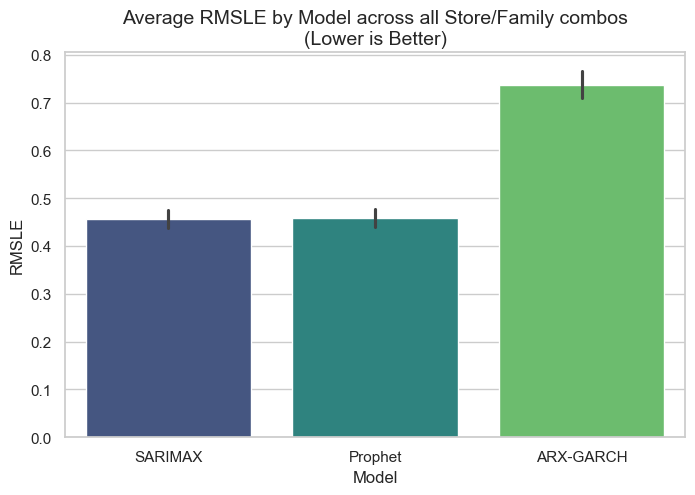

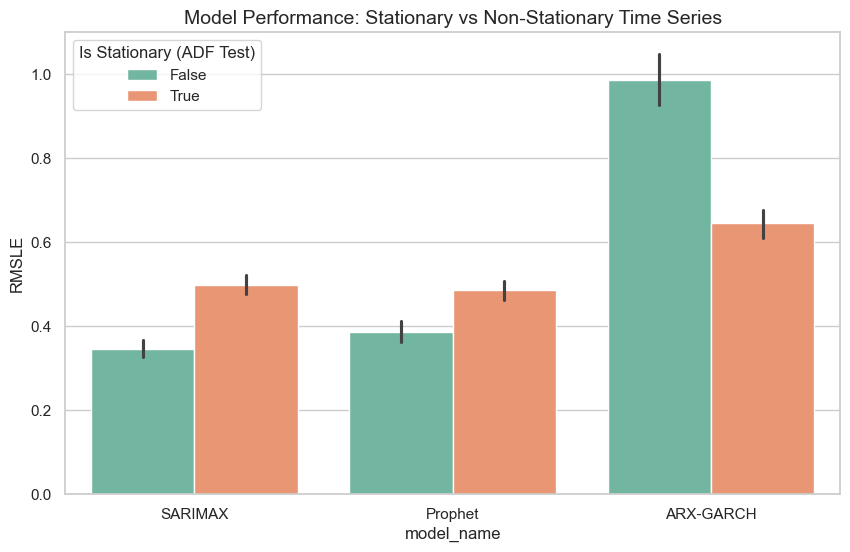

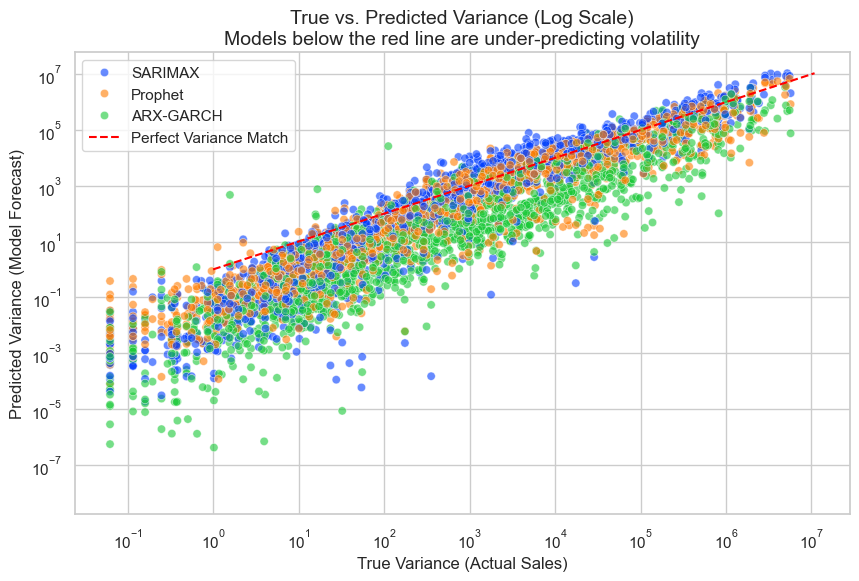

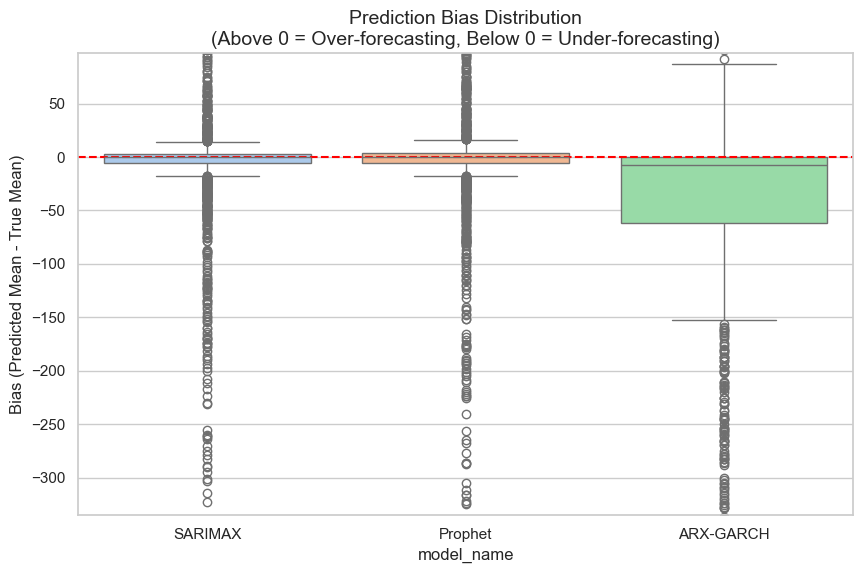

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df_eval = pd.read_csv('classical_timeseries_evaluation_metrics.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# INSIGHT 1: Overall Model Performance (Who wins on average?)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=df_eval, x='model_name', y='rmsle', errorbar='ci', palette='viridis')
plt.title('Average RMSLE by Model across all Store/Family combos\n(Lower is Better)', fontsize=14)
plt.ylabel('RMSLE')
plt.xlabel('Model')
plt.show()

# ---------------------------------------------------------
# INSIGHT 2: How do models react to Non-Stationary data?
# ---------------------------------------------------------
# If data is non-stationary, it means it has trends/shocks that differencing (d=1) tries to fix.
plt.figure(figsize=(10, 6))
sns.barplot(data=df_eval, x='model_name', y='rmsle', hue='is_stationary', palette='Set2')
plt.title('Model Performance: Stationary vs Non-Stationary Time Series', fontsize=14)
plt.ylabel('RMSLE')
plt.legend(title='Is Stationary (ADF Test)')
plt.show()

# ---------------------------------------------------------
# INSIGHT 3: Volatility Capture (Do models under-predict spikes?)
# ---------------------------------------------------------
# We use log-scale because sales variance spans massive orders of magnitude
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eval, x='true_variance_sales', y='pred_variance', 
                hue='model_name', alpha=0.6, palette='bright')
# Plot the "Perfect Prediction" diagonal line
max_val = max(df_eval['true_variance_sales'].max(), df_eval['pred_variance'].max())
plt.plot([1, max_val], [1, max_val], color='red', linestyle='--', label='Perfect Variance Match')

plt.xscale('log')
plt.yscale('log')
plt.title('True vs. Predicted Variance (Log Scale)\nModels below the red line are under-predicting volatility', fontsize=14)
plt.xlabel('True Variance (Actual Sales)')
plt.ylabel('Predicted Variance (Model Forecast)')
plt.legend()
plt.show()

# ---------------------------------------------------------
# INSIGHT 4: Bias (Over-forecasting vs Under-forecasting)
# ---------------------------------------------------------
# Calculate Bias (Predicted Mean - True Mean). Positive = Over-forecasting.
df_eval['mean_bias'] = df_eval['pred_mean'] - df_eval['true_mean_sales']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eval, x='model_name', y='mean_bias', palette='pastel')
plt.axhline(0, color='red', linestyle='--')
plt.title('Prediction Bias Distribution\n(Above 0 = Over-forecasting, Below 0 = Under-forecasting)', fontsize=14)
plt.ylabel('Bias (Predicted Mean - True Mean)')
# Limit Y axis to zoom in on the bulk of the data, ignoring extreme outliers
plt.ylim(df_eval['mean_bias'].quantile(0.05), df_eval['mean_bias'].quantile(0.95))
plt.show()


For an interactive streamlit dashboard of the Classical Timeseries Results, please run the following in your terminal:

streamlit run classical_dashboard.py

What these tools will teach you for your ML models:

If Prophet dominates: It means yearly/weekly seasonality is the strongest signal. For ML, you must rely heavily on temporal features (day_of_week, month, week_of_year).

If SARIMAX dominates: It means autoregression (recent momentum) is the strongest signal. For ML, your explicit lag features (sales_lag_16, sales_lag_21) will be your most important variables.

If all classical models show high bias (over-forecasting): It implies that recent trends drastically changed right before the test set, and classical models couldn't pivot fast enough. In ML, adding rolling windows (sales_7_day_mean) will fix this!


## ML timeseries models

---
### 💡 Next Steps for Modeling
1. **Feature Engineering:** Create robust lag variables (`t-16` to `t-30`) to capture the rigid weekly seasonality without leaking data into the 15-day test set.
2. **Boolean Flags:** Create flags for the 2016 Earthquake, Paydays, and "Make-up Work Days" to help tree-based models understand structural anomalies.
3. **Algorithm Selection:** Given the sheer number of distinct time series (54 stores $\times$ 33 families = 1,782 series) and the categorical complexity, global GBDT models (LightGBM, XGBoost) using natively handled categoricals will likely outperform traditional statistical models (ARIMA) or heavy deep learning models.